# Model Selection: Decision Tree → Random Forest → LightGBM

This notebook is an exploration of model selection. As I already know gradient boosting fixes a lot of the problems that Random Forest has, and in turn Random Forest fixes the overfitting problem of decision trees, I still want to go through the process of comparison on the data. 

In a real deployment setting we want the fastest and simplest model that does the job. 

This notebook is probably going to justify the choice of LightGBM for carbon intensity forecasting by comparing it against simpler tree-based alternatives. So my hypothesis is that LightGBM is the best model for this problem; but let's test that. 

The three models represent a progression:
- **Decision Tree** — interpretable but overfits without constraints
- **Random Forest** — fixes overfitting via bagging and averaging, but has an accuracy ceiling
- **LightGBM** — sequential boosting on residuals, captures complex feature interactions

### The plan

Evaluate the three models using **5-fold walk-forward cross-validation** with a gap of 48 periods (1 day) to prevent lag feature leakage. 
The metric I will compare is **pinball loss at α=0.5**, equivalent to ½ × MAE — lower is better.

In [1]:
# Path stuff for notebooks 
import sys
sys.path.insert(0, "..")
import os
os.chdir("..")



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
# Import the models I want to compare
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor

# Import local functions I have written
from src.features.store import load_features
from src.models.forecasting.cv import time_series_cv_split
from src.models.forecasting.metrics import pinball_loss

## Load Features

Note: requires the feature_pipeline to have been run before 

`uv run python src/features/run_feature_pipeline.py`

In [2]:
df = load_features()
print(f"{len(df):,} rows, {df.shape[1]} columns")

y = df["carbon_intensity"]

# Drop the target and the date column
X = df.drop(columns=["carbon_intensity", "settlement_period"])

print(f"Features: {X.shape[1]}  |  Target: carbon_intensity")
print(f"Target range: {y.min():.1f} – {y.max():.1f} gCO2/kWh")

{"timestamp": "2026-03-16T21:51:47.466376+00:00", "level": "INFO", "message": "Loaded 20164 rows from data/features/features_2026-03-16.parquet", "logger": "src.features.store"}


20,164 rows, 43 columns
Features: 41  |  Target: carbon_intensity
Target range: 24.0 – 293.0 gCO2/kWh


> Note on why we drop the date column: The model cannot handle times, nor is able to do maths on raw datetimes. It doesn't know Tuesday is closer to Wednesday than it is to Sunday. But that's why I engineered some simpler numerical features, namely: `hour_of_day`, `day_of_week`, `season_sin`, `season_cos`

## Evaluation Helper Function

Runs a 5-fold walk-forward OOF evaluation for any scikit-learn compatible model.
Each validation prediction is made by a model that never saw that row during training.
Walk forward simply means that the data selected for each fold is ahead of the last section. This is different to k-fold which would randomly scatter the selection, which is unsuitable for time series becuase the model would "see the future". 
OOF means that the predictions are collected across all of the test folds. Every row gets predicted exactly once by a model that never trained on that row. Then pinball-loss is calculated against that. 


In [3]:
def evaluate_model(model, X: pd.DataFrame, y: pd.Series, label: str) -> dict:
    cv = time_series_cv_split(len(X), n_splits=5, gap=48)
    oof_preds = np.full(len(X), np.nan)

    for fold, (train_idx, val_idx) in enumerate(cv, 1):
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        oof_preds[val_idx] = model.predict(X.iloc[val_idx])
        print(f"  {label} — fold {fold}/5", end="\r")

    mask = ~np.isnan(oof_preds)
    loss = pinball_loss(0.5, oof_preds[mask], y.values[mask])
    mae = loss * 2
    print(f"  {label}: pinball={loss:.3f}  MAE≈{mae:.2f} gCO2/kWh          ")
    return {"model": label, "pinball_loss": loss, "mae": mae}

## 1. Decision Tree — Unconstrained

Allowed to split all the way to individual rows. Training error ≈ 0, but generalisation is poor — this is the overfitting baseline.

In [4]:
results = []

# A Decision Tree with unlimited depth - which I know will overfit
tree = DecisionTreeRegressor(random_state=42)
trees = evaluate_model(tree, X, y, "Decision Tree (unlimited depth)")
results.append(trees)

  Decision Tree (unlimited depth): pinball=2.720  MAE≈5.44 gCO2/kWh          


## 2. Decision Tree — Constrained

The simplest fix for overfitting: limit how deep the tree can grow.

In [5]:
# Decision Tree (max_depth=5) for a more constrained model and prevent overfitting
constrained_tree = DecisionTreeRegressor(max_depth=5, random_state=42)
constrained_trees = evaluate_model(constrained_tree, X, y, "Decision Tree (limited depth)")
results.append(constrained_trees)

  Decision Tree (limited depth): pinball=2.615  MAE≈5.23 gCO2/kWh          


Note on this result: I was expecting the pinball loss to go down quite a bit, but actually, it's only a marginal improvement. This goes to show that a single decision tree can't capture the complexity of this problem!

## 3. Random Forest

Up to 500 trees, each on a bootstrap sample with random feature subsets. Individual trees grow deep and overfit but overfitting is handled by averaging, not constraining depth.

In [6]:
# Execture for 250, 500, and 750 and see the diminishing returns
# Use n_jobs=-1 to parallelise across cores, random_state=42

for n in [25, 50,125, 250, 500, 750]:
    rf_regressor = RandomForestRegressor(n_estimators=n, n_jobs=-1,random_state=42)
    rf_evaluation = evaluate_model(rf_regressor, X, y, f"Random Forest ({n} trees)")
    results.append(rf_evaluation)


  Random Forest (25 trees): pinball=1.796  MAE≈3.59 gCO2/kWh          
  Random Forest (50 trees): pinball=1.760  MAE≈3.52 gCO2/kWh          
  Random Forest (125 trees): pinball=1.742  MAE≈3.48 gCO2/kWh          
  Random Forest (250 trees): pinball=1.731  MAE≈3.46 gCO2/kWh          
  Random Forest (500 trees): pinball=1.727  MAE≈3.45 gCO2/kWh          
  Random Forest (750 trees): pinball=1.727  MAE≈3.45 gCO2/kWh          


Note: Here we see the textbook diminishing returns that we expect from Random Forest. Adding more and more trees after a few hundred hardly decreses the error. After 250 (which was my initial guess at n_estimators) the pinball loss hardly drops and levels off after 500. 

## 4. LightGBM

Gradient boosting with histogram binning and leaf-wise growth. Same hyperparameters as `trainer.py` but with `objective='regression'` (MSE) so the comparison is fair — all models optimising the same loss.

In [7]:
# Use objective='regression', match the other params from trainer.py, verbose=-1, random_state=42
lgbm_regressor = LGBMRegressor(objective='regression', verbose=-1, random_state=42)
lgbm_eval_1 = evaluate_model(lgbm_regressor, X, y, "LightGBM")
results.append(lgbm_eval_1)

  LightGBM: pinball=1.734  MAE≈3.47 gCO2/kWh          


Note: 1) This result is NOT what I was expecting. I thought there would be a small but meaningful decrease in loss as sequential boosting on residuals captures more complex feature interactions that parrelel trees cannot. LightGBM is basically identical to Random Forest in these results, and slightly worse than RF at 500 trees. LightGBM is basically identical to Random Forest here, and slightly worse than RF at 500 trees.
2) I noticed the LightGBM train much faster on my data than RF - especially the runs with a few hundred trees. The faster training is due to histogram binning
3) I haven't tested this, but RF should be significantly faster at making predictions, once we have a trained model. Both will be fast, but that difference could matter in production on large volumes of data. 

In [8]:
# Use objective='regression', match the other params from trainer.py, verbose=-1, random_state=42
lgbm_regressor = LGBMRegressor(objective='regression', verbose=-1, random_state=42, n_estimators=1000)
lgbm_eval_2 = evaluate_model(lgbm_regressor, X, y, "LightGBM-1000 trees")
results.append(lgbm_eval_2)

  LightGBM-1000 trees: pinball=1.767  MAE≈3.53 gCO2/kWh          


## Conclusion

The winning model was actually Random Forest with 750 trees, which was not what I expected — so it is good to experiment with real data. The 750 model is only a tiny bit better than the 500 model, which was quicker to train, so in production I would consider those trade-offs carefully.

When I moved onto LightGBM I expected a small but significant reduction in pinball loss, but that did not happen. Trying to tune the model with more trees and double the leaves actually made things worse on both counts. So the default parameters worked well for this dataset.

You might think, given that RF is competitive and potentially faster at prediction, that I would choose it for production. But I would definitely go with LightGBM — because it is the only model of the three that can natively predict quantiles. That is what I need for my carbon intensity forecasts: P10, P50, and P90 uncertainty bounds to make risk-aware EV charging decisions. Random Forest cannot do this natively.

LightGBM is used in `src/models/forecasting/trainer.py` with `objective='quantile'` and `alpha=0.1/0.5/0.9` to produce the P10/P50/P90 forecasts.

In [10]:
# Use objective='regression', match the other params from trainer.py, verbose=-1, random_state=42
lgbm_regressor = LGBMRegressor(objective='regression', verbose=-1, random_state=42, n_leaves=63, n_estimators=1000)
lgbm_eval_4 = evaluate_model(lgbm_regressor, X, y, "LightGBM-63 leaves, 1000 trees")
results.append(lgbm_eval_4)

  LightGBM-63 leaves, 1000 trees: pinball=1.767  MAE≈3.53 gCO2/kWh          


## Results

                          Model Pinball Loss (α=0.5)    Approx MAE
      Random Forest (750 trees)                1.727 3.45 gCO2/kWh
      Random Forest (500 trees)                1.727 3.45 gCO2/kWh
      Random Forest (250 trees)                1.731 3.46 gCO2/kWh
                       LightGBM                1.734 3.47 gCO2/kWh
             LightGBM-63 leaves                1.734 3.47 gCO2/kWh
      Random Forest (125 trees)                1.742 3.48 gCO2/kWh
       Random Forest (50 trees)                1.760 3.52 gCO2/kWh
            LightGBM-1000 trees                1.767 3.53 gCO2/kWh
 LightGBM-63 leaves, 1000 trees                1.767 3.53 gCO2/kWh
       Random Forest (25 trees)                1.796 3.59 gCO2/kWh
  Decision Tree (limited depth)                2.615 5.23 gCO2/kWh
Decision Tree (unlimited depth)                2.720 5.44 gCO2/kWh


FileNotFoundError: [Errno 2] No such file or directory: '../docs/images/model_selection.png'

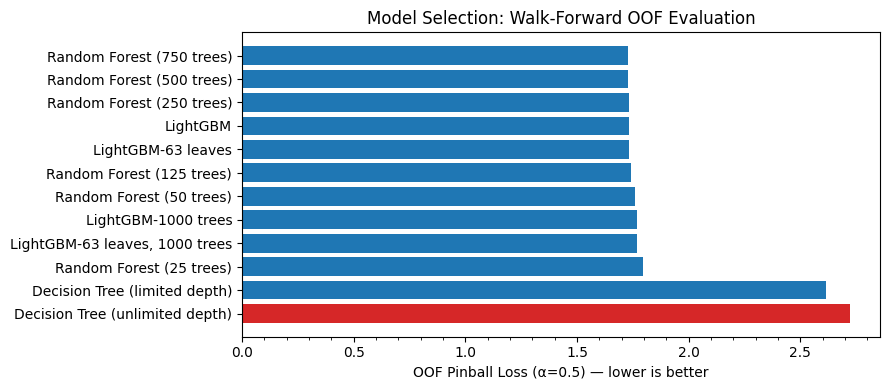

In [11]:
results_df = pd.DataFrame(results).sort_values("pinball_loss")

display_df = results_df.copy()
display_df["pinball_loss"] = display_df["pinball_loss"].map("{:.3f}".format)
display_df["mae"] = display_df["mae"].map("{:.2f} gCO2/kWh".format)
display_df.columns = ["Model", "Pinball Loss (α=0.5)", "Approx MAE"]
print(display_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
colours = ["#d62728" if "unlimited" in r else "#1f77b4" for r in results_df["model"]]
ax.barh(results_df["model"], results_df["pinball_loss"], color=colours)
ax.set_xlabel("OOF Pinball Loss (α=0.5) — lower is better")
ax.set_title("Model Selection: Walk-Forward OOF Evaluation")
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../docs/images/model_selection.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → docs/images/model_selection.png")

## Conclusion

The winning model was actually Random Forest with 750 trees, which was not what I expected — so it is good to experiment with real data. The 750 model is only a tiny bit better than the 500 model, which was quicker to train, so in production I would consider those trade-offs carefully.

When I moved onto LightGBM I expected a small but significant reduction in pinball loss, but that did not happen. Trying to tune the model with more trees and double the leaves actually made things worse on both counts. So the default parameters worked well for this dataset.

You might think, given that RF is competitive and potentially faster at prediction, that I would choose it for production. But I would definitely go with LightGBM — because it is the only model of the three that can natively predict quantiles. That is what I need for my carbon intensity forecasts: P10, P50, and P90 uncertainty bounds to make risk-aware EV charging decisions. Random Forest cannot do this natively.

LightGBM is used in `src/models/forecasting/trainer.py` with `objective='quantile'` and `alpha=0.1/0.5/0.9` to produce the P10/P50/P90 forecasts.